<div style="text-align: center;">
  <h1>Breaking IBM's QPUs</h1>
</div>


In [9]:
# Qiskit setup
from qiskit_ibm_runtime import QiskitRuntimeService

In [14]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Options, Session, SamplerV2 as Sampler
backend_sim = AerSimulator()
simulator = AerSimulator()

#Import an estimator, this time from qiskit (we import from Runtime for real hardware)
from qiskit.primitives import BackendSampler
sampler = BackendSampler(backend = backend_sim)
import numpy as np
from qiskit.visualization import plot_bloch_vector, plot_histogram
import matplotlib.pyplot as plt

from qiskit.circuit import QuantumRegister, ClassicalRegister, QuantumCircuit, Parameter, Gate
from qiskit import QuantumCircuit, transpile
from qiskit.result import marginal_counts
from qiskit.circuit.library import QFT

C:\Users\lucas\AppData\Local\Temp\ipykernel_23448\3078084975.py:8: DeprecationWarning: The class ``qiskit.primitives.backend_sampler.BackendSampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `BackendSampler` class is `BackendSamplerV2`.
  sampler = BackendSampler(backend = backend_sim)


In [84]:
T = 1e-5
N = 300

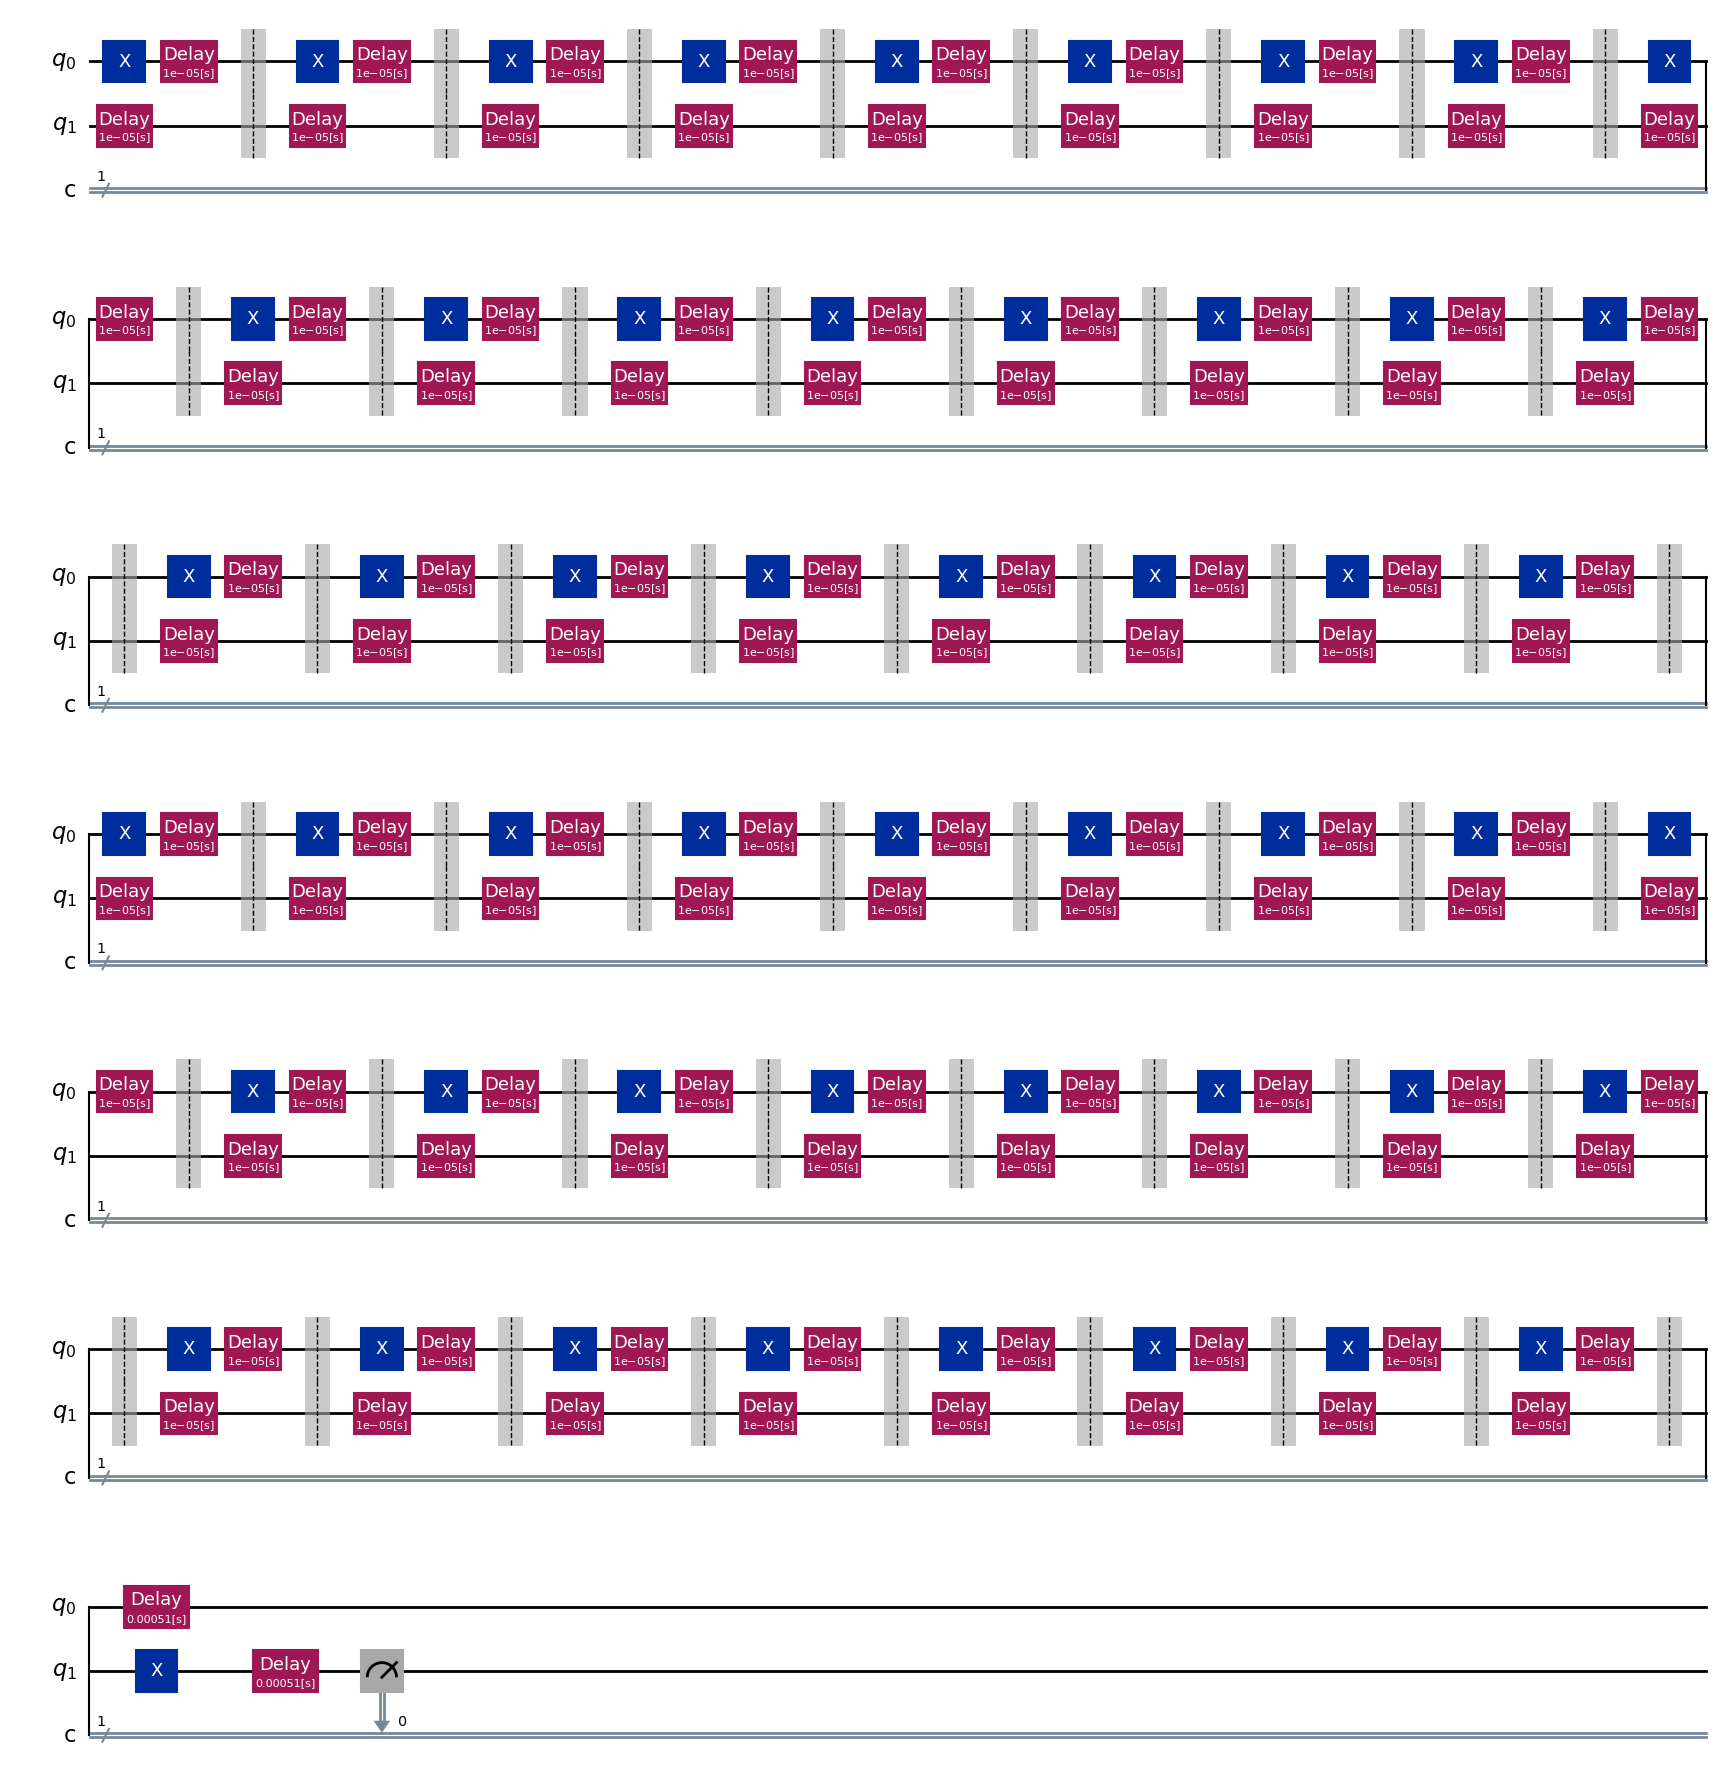

In [70]:
qc = QuantumCircuit(2,1)

for i in range(N):
    qc.x(0)
    qc.delay(T,unit="s") 
    qc.barrier()


qc.x(1)
qc.delay((N+1)*T, unit="s")
qc.measure(1,0)

qc.draw('mpl')

In [137]:
from qiskit.primitives import BackendSampler
service = QiskitRuntimeService(channel='ibm_quantum')
backend = service.least_busy()
print(backend.name)
sampler = Sampler(mode=backend)
sampler.options.default_shots = 100

ibm_brisbane


In [72]:
# transpiling the circuits
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

physical_qubit = [62, 61]

pm = generate_preset_pass_manager(optimization_level=3, backend=backend, scheduling_method='asap', initial_layout=physical_qubit) 
qc_transpiled = pm.run(qc)

KeyboardInterrupt: 

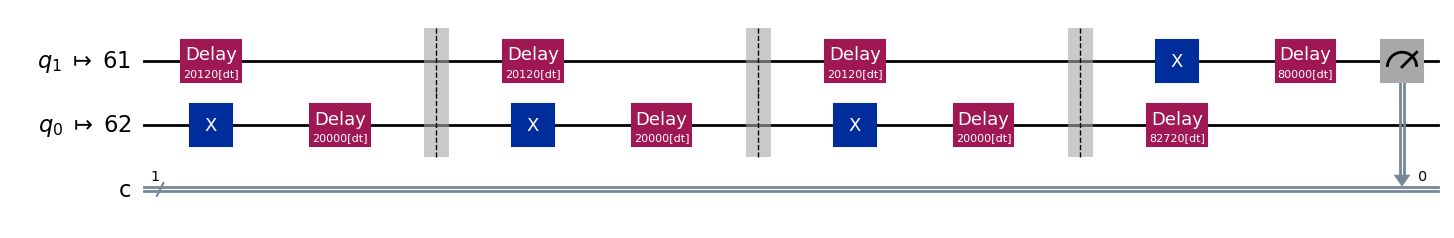

In [ ]:
qc_transpiled.draw('mpl', idle_wires=False)

In [ ]:
sampler = Sampler(mode=backend)
job = sampler.run([(qc_transpiled)], shots = 100)
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: cz5fx6c39f40008sjmr0
>>> Job Status: QUEUED


In [ ]:
print(f">>> Job Status: {job.status()}")

>>> Job Status: DONE


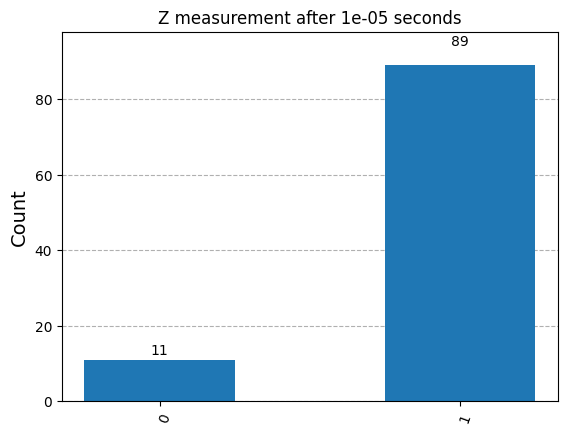

In [ ]:
res = job.result()
res[0].data.c.get_counts()
plot_histogram(res[0].data.c.get_counts(),title= f"Z measurement after {T} seconds")

In [ ]:

delays = np.linspace(0,2e-3, 40) 
qcs = []
for delay in delays:
  
    qc = QuantumCircuit(2,1)

    for i in range(N):
        qc.x(0)
        qc.delay(T,unit="s") 
        qc.barrier()

    qc.x(1)
    qc.delay((N)*T+delay, unit="s")
    qc.measure(1,0)
    qcs.append(qc)


In [109]:
physical_qubit = [62, 61]
pm = generate_preset_pass_manager(optimization_level=3, backend=backend, scheduling_method='asap', timing_constraints="1" , initial_layout=physical_qubit) 
qcs_ibm = [pm.run(qc) for qc in qcs]

C:\Users\lucas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\qiskit\circuit\duration.py:37: UserWarning: Duration is rounded to 6102564 [dt] = 3.051282e-03 [s] from 3.051282e-03 [s]
  warnings.warn(
C:\Users\lucas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\qiskit\circuit\duration.py:37: UserWarning: Duration is rounded to 6205128 [dt] = 3.102564e-03 [s] from 3.102564e-03 [s]
  warnings.warn(
C:\Users\lucas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\qiskit\circuit\duration.py:37: UserWarning: Duration is rounded to 6307692 [dt] = 3.153846e-03 [s] from 3.153846e-03 [s]
  warnings.warn(
C:\Users\lucas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\qiskit\circuit\duration.py:37:

In [110]:
num_shots = 100
job = sampler.run(qcs_ibm, shots = num_shots)
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: cz5g4nt39f40008sjnx0
>>> Job Status: QUEUED


In [119]:
print(f">>> Job Status: {job.status()}")

>>> Job Status: RUNNING


In [120]:
res = job.result()

In [121]:
# Extract the probabilities of measuring 1 for each delay
probs = []
sigmas = []
for i in range(len(delays)):
    counts = res[i].data.c.get_counts()
    probs.append(counts.get("1",0)/num_shots) 
    sigmas.append(np.sqrt((probs[i]*(1-probs[i]))/num_shots))

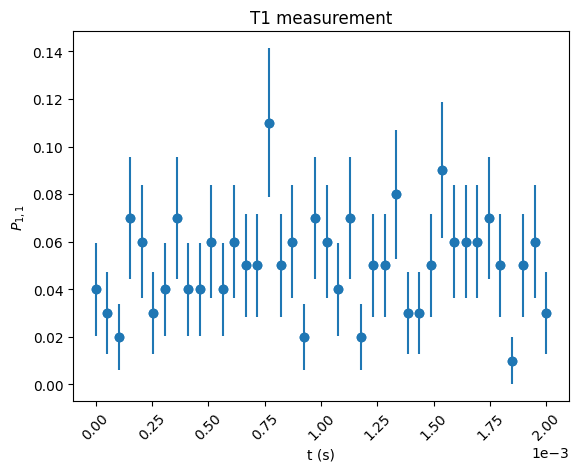

In [122]:
import matplotlib.pyplot as plt

plt.scatter(delays, probs)
plt.xlabel(r"t (s)")
plt.ylabel(r"$P_{1,1}$")
plt.errorbar(delays, probs, yerr=sigmas, fmt='o')
plt.title("T1 measurement")

plt.xticks(rotation=45)  # Rotate labels by 45 degrees to prevent overlap
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))  # Use scientific notation for x-axis
plt.show()

In [28]:
import networkx as nx
import matplotlib.pyplot as plt

Coupling Map: [[1, 0], [2, 1], [3, 2], [4, 3], [4, 5], [4, 15], [6, 5], [6, 7], [7, 8], [8, 9], [10, 9], [10, 11], [11, 12], [12, 17], [13, 12], [14, 0], [14, 18], [15, 22], [16, 8], [16, 26], [17, 30], [18, 19], [20, 19], [20, 33], [21, 20], [21, 22], [22, 23], [24, 23], [24, 34], [25, 24], [26, 25], [27, 26], [28, 27], [28, 29], [28, 35], [30, 29], [30, 31], [31, 32], [32, 36], [33, 39], [34, 43], [35, 47], [36, 51], [37, 38], [39, 38], [40, 39], [40, 41], [41, 53], [42, 41], [42, 43], [43, 44], [44, 45], [46, 45], [46, 47], [48, 47], [48, 49], [50, 49], [50, 51], [52, 37], [52, 56], [53, 60], [54, 45], [54, 64], [55, 49], [55, 68], [56, 57], [57, 58], [58, 59], [58, 71], [59, 60], [60, 61], [62, 61], [62, 63], [62, 72], [63, 64], [65, 64], [65, 66], [67, 66], [67, 68], [69, 68], [69, 70], [73, 66], [74, 70], [74, 89], [75, 90], [76, 75], [77, 71], [77, 76], [77, 78], [79, 78], [79, 80], [80, 81], [81, 72], [81, 82], [82, 83], [83, 92], [84, 83], [85, 73], [85, 84], [85, 86], [86, 87

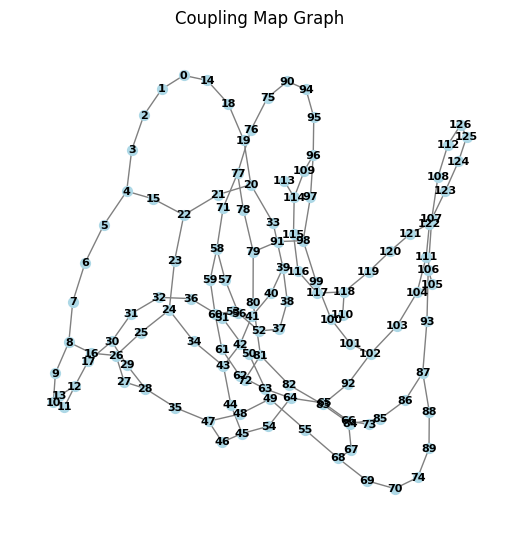

In [31]:
config = backend.configuration()
coupling_map = config.coupling_map
print("Coupling Map:", coupling_map)


# Créer un graphe à partir de la carte de couplage
G = nx.Graph()
G.add_edges_from(coupling_map)

# Dessiner le graphe
plt.figure(figsize=(5,5))
pos = nx.spring_layout(G, seed=42)  # Positionnement des nœuds
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=50, font_size=8, font_weight='bold', edge_color='gray')
plt.title("Coupling Map Graph")
plt.show()

In [155]:
from qiskit import QuantumCircuit
from qiskit.providers.ibmq import QiskitRuntimeService
from qiskit.primitives import BackendSampler
import numpy as np
import matplotlib.pyplot as plt

# Initialize the BackendSampler
service = QiskitRuntimeService(channel='ibm_quantum')
backend = service.least_busy()
print("Using backend:", backend.name)

sampler = BackendSampler(backend)
sampler.options.default_shots = 100

# Define parameters
N = 3  # Number of X operations
T = 1e-6  # Delay time in seconds
delays = np.linspace(0, 2e-3, 40)  # Delay times for T1 measurement
num_shots = 100  # Number of shots for each circuit

# Get backend configuration
config = backend.configuration()
coupling_map = config.coupling_map

# Create a dictionary to find neighbors
neighbors = {}
for pair in coupling_map:
    if pair[0] not in neighbors:
        neighbors[pair[0]] = []
    if pair[1] not in neighbors:
        neighbors[pair[1]] = []
    neighbors[pair[0]].append(pair[1])
    neighbors[pair[1]].append(pair[0])

# Choose physical qubits for execution
physical_qubit = [0, 6, 12]  # Adjust if needed

# Initialize quantum circuits
qcs = []
num_qubits = len(physical_qubit)

for delay in delays:
    qc = QuantumCircuit(num_qubits, num_qubits)

    # Apply N X operations on each qubit in parallel
    for qubit in range(num_qubits):
        for _ in range(N):
            qc.x(qubit)
            qc.delay(T, unit="s")
        qc.barrier()

    # Measure T1 on a neighboring qubit for each qubit
    for qubit in range(num_qubits):
        if qubit in neighbors:
            neighbor = neighbors[qubit][0]  # Choose the first neighbor
            qc.x(neighbor)
            qc.delay(N * T + delay, unit="s")
            qc.measure(neighbor, qubit)

    qcs.append(qc)

# Execute the circuits
job = sampler.run(qcs, shots=num_shots)
res = job.result()

# Extract results
probs = []
sigmas = []

for i in range(len(qcs)):
    quasi_probs = res.quasi_dists[i]  # Extract quasi-probabilities

    # Compute probability of measuring '1' across all states
    prob = sum(val for key, val in quasi_probs.items() if bin(key).count('1') == 1)

    probs.append(prob)
    sigmas.append(np.sqrt((prob * (1 - prob)) / num_shots))

# Plot results
plt.figure(figsize=(10, 6))
plt.errorbar(delays, probs, yerr=sigmas, fmt='o', label="T1 Measurement")

plt.xlabel(r"t (s)")
plt.ylabel(r"$P_{1,1}$")
plt.title("T1 Measurement for 3 Qubits")
plt.xticks(rotation=45)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.legend()
plt.show()


ModuleNotFoundError: No module named 'qiskit.providers.ibmq'

[]


ValueError: x and y must be the same size

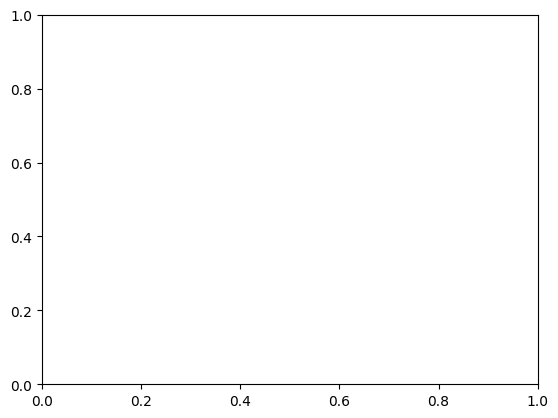

In [151]:
print(probs)
plt.scatter(delays, probs)
plt.xlabel(r"t (s)")
plt.ylabel(r"$P_{1,1}$")
plt.errorbar(delays, probs, yerr=sigmas, fmt='o')
plt.title("T1 measurement")

plt.xticks(rotation=45)  # Rotate labels by 45 degrees to prevent overlap
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))  # Use scientific notation for x-axis
plt.show()